In [1]:
import numpy as np
import random
from collections import Counter

# =========================
# LOAD CORPUS
# =========================

def load_corpus(file_path):
    corpus = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            tokens = line.strip().split()
            if len(tokens) > 2:
                corpus.append(tokens)
    return corpus


corpus = load_corpus("corpus.txt")

# =========================
# BUILD VOCAB
# =========================

all_tokens = [w for sent in corpus for w in sent]
word_counts = Counter(all_tokens)

min_count = 2
vocab = [w for w, c in word_counts.items() if c >= min_count]

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

vocab_size = len(vocab)

# Convert corpus to indices
indexed_corpus = [
    [word2idx[w] for w in sent if w in word2idx]
    for sent in corpus
]

# =========================
# DATA GENERATION
# =========================

def generate_skipgram_data(corpus, window):
    pairs = []
    for sent in corpus:
        for i, target in enumerate(sent):
            for j in range(i - window, i + window + 1):
                if j != i and 0 <= j < len(sent):
                    pairs.append((target, sent[j]))
    return pairs


def generate_cbow_data(corpus, window):
    data = []
    for sent in corpus:
        for i in range(len(sent)):
            context = []
            for j in range(i - window, i + window + 1):
                if j != i and 0 <= j < len(sent):
                    context.append(sent[j])
            if context:
                data.append((context, sent[i]))
    return data


# =========================
# UTILS
# =========================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# word_freqs = np.array([word_counts[idx2word[i]] for i in range(vocab_size)])
# word_freqs = word_freqs ** 0.75
# word_freqs = word_freqs / np.sum(word_freqs)
def get_negative_samples(k):
    return random.choices(range(vocab_size), k=k)


# =========================
# SKIP-GRAM TRAINING (NEG SAMPLING)
# =========================

def train_skipgram(data, dim, neg_samples, epochs=3, lr=0.01):
    W = np.random.randn(vocab_size, dim)
    W_prime = np.random.randn(vocab_size, dim)

    for epoch in range(epochs):
        loss = 0

        for target, context in data:
            v = W[target]
            u = W_prime[context]

            # Positive
            score = sigmoid(np.dot(v, u))
            loss += -np.log(score + 1e-9)

            grad = score - 1

            W[target] -= lr * grad * u
            W_prime[context] -= lr * grad * v

            # Negative samples
            negatives = get_negative_samples(neg_samples)

            for neg in negatives:
                u_neg = W_prime[neg]

                score_neg = sigmoid(np.dot(v, u_neg))
                loss += -np.log(1 - score_neg + 1e-9)

                grad_neg = score_neg

                W[target] -= lr * grad_neg * u_neg
                W_prime[neg] -= lr * grad_neg * v

        if (epoch == 0 or (epoch+1)%5 == 0):
            print(f"[SkipGram] Epoch {epoch+1}, Loss: {loss:.4f}")

    return W


# =========================
# CBOW TRAINING
# =========================

def train_cbow(data, dim, epochs=10, lr=0.01):
    W = np.random.randn(vocab_size, dim)
    W_prime = np.random.randn(vocab_size, dim)

    for epoch in range(epochs):
        loss = 0

        for context, target in data:
            context_vecs = W[context]
            v_context = np.mean(context_vecs, axis=0)

            u = W_prime[target]

            score = sigmoid(np.dot(v_context, u))
            loss += -np.log(score + 1e-9)

            grad = score - 1

            for idx in context:
                W[idx] -= lr * grad * u / len(context)

            W_prime[target] -= lr * grad * v_context

        if (epoch == 0 or (epoch+1)%5 == 0):
            print(f"[CBOW] Epoch {epoch+1}, Loss: {loss:.4f}")

    return W


# =========================
# EXPERIMENTS
# =========================

# configs = [
#     {"dim": 50, "window": 2, "neg": 5},
#     {"dim": 100, "window": 5, "neg": 5},
#     {"dim": 100, "window": 10, "neg": 5},
#     {"dim": 100, "window": 5, "neg": 10},
# ]

# results = []

# for cfg in configs:
#     print("\n==============================")
#     print(f"Config: {cfg}")
#     print("==============================")

#     sg_data = generate_skipgram_data(indexed_corpus, cfg["window"])
#     cbow_data = generate_cbow_data(indexed_corpus, cfg["window"])

#     sg_embeddings = train_skipgram(
#         sg_data,
#         dim=cfg["dim"],
#         neg_samples=cfg["neg"]
#     )

#     cbow_embeddings = train_cbow(
#         cbow_data,
#         dim=cfg["dim"]
#     )

#     results.append((cfg, sg_embeddings, cbow_embeddings))

In [2]:
sg_data = generate_skipgram_data(indexed_corpus, 5)

In [ ]:
sg_embeddings = train_skipgram(
    sg_data,
    dim=100,
    neg_samples=5,
    epochs=50
)

[SkipGram] Epoch 1, Loss: 2281295.2835
[SkipGram] Epoch 2, Loss: 984537.7542
[SkipGram] Epoch 3, Loss: 654708.1460
[SkipGram] Epoch 4, Loss: 507956.2808
[SkipGram] Epoch 5, Loss: 427079.2967
[SkipGram] Epoch 6, Loss: 374781.2094
[SkipGram] Epoch 7, Loss: 336990.3067
[SkipGram] Epoch 8, Loss: 307225.4348
[SkipGram] Epoch 9, Loss: 286101.5684
[SkipGram] Epoch 10, Loss: 269124.2806
[SkipGram] Epoch 11, Loss: 254994.2161
[SkipGram] Epoch 12, Loss: 243120.2201
[SkipGram] Epoch 13, Loss: 233343.3986
[SkipGram] Epoch 14, Loss: 226058.0500
[SkipGram] Epoch 15, Loss: 219333.9373
[SkipGram] Epoch 16, Loss: 213068.8125
[SkipGram] Epoch 17, Loss: 208266.0257
[SkipGram] Epoch 18, Loss: 203640.9443
[SkipGram] Epoch 19, Loss: 199662.1222
[SkipGram] Epoch 20, Loss: 196470.0782
[SkipGram] Epoch 21, Loss: 193547.9640
[SkipGram] Epoch 22, Loss: 190371.4965
[SkipGram] Epoch 23, Loss: 187893.3117
[SkipGram] Epoch 24, Loss: 186018.7010
[SkipGram] Epoch 25, Loss: 183775.3508
[SkipGram] Epoch 26, Loss: 182312

In [7]:
def cosine_similarity(vec, matrix):
    dot = np.dot(matrix, vec)
    norm_vec = np.linalg.norm(vec)
    norm_matrix = np.linalg.norm(matrix, axis=1)

    return dot / (norm_matrix * norm_vec + 1e-9)

def get_nearest_neighbors(word, embeddings, top_k=5):
    if word not in word2idx:
        print(f"{word} not in vocab")
        return []

    idx = word2idx[word]
    vec = embeddings[idx]

    sims = cosine_similarity(vec, embeddings)

    top_indices = np.argsort(-sims)[:top_k+1]

    neighbors = []
    for i in top_indices:
        if idx2word[i] != word:
            neighbors.append((idx2word[i], sims[i]))

    return neighbors[:top_k]

In [ ]:
print("\n=== Nearest Neighbors (SkipGram) ===")

words = ["research", "student", "phd", "exam"]

for w in words:
    neighbors = get_nearest_neighbors(w, sg_embeddings)
    print(f"{w} -> {neighbors}")


=== Nearest Neighbors (SkipGram) ===
research -> ['industry', 'work', 'our', 'leading', 'fundamental']
student -> ['no', 'should', 'candidacy', 'progress', 'comprehensive']
phd -> ['mtech', 'dual', 'degree', 'publications', 'program']
exam -> ['application', 'comprehend', 'supervision', 'certificate', 'proceed']


In [ ]:
print("\n=== Nearest Neighbors (SkipGram) ===")

words = ["research", "student", "phd", "exam"]

for w in words:
    neighbors = get_nearest_neighbors(w, sg_embeddings)
    print(f"{w} -> {neighbors}")


=== Nearest Neighbors (SkipGram) ===
research -> ['work', 'projects', 'proposal', 'encouraging', 'art']
student -> ['admitted', 'thesis', 'dean', 'sota', 'should']
phd -> ['mtech', 'dual', 'degree', 'program', 'jpd']
exam -> ['state', 'departments', 'visiting', 'courses', 'established']


In [8]:
def analogy(a, b, c, embeddings, top_k=3):
    for w in [a, b, c]:
        if w not in word2idx:
            print(f"{w} not in vocab")
            return []

    vec = embeddings[word2idx[b]] - embeddings[word2idx[a]] + embeddings[word2idx[c]]

    sims = cosine_similarity(vec, embeddings)

    top_indices = np.argsort(-sims)[:top_k+5]

    results = []
    for i in top_indices:
        word = idx2word[i]
        if word not in [a, b, c]:
            results.append(word)

    return results[:top_k]

In [ ]:
print("\n=== Analogies ===")

# 1
print("UG : BTech :: PG :", analogy("ug", "btech", "pg", sg_embeddings))

# 2
print("student : professor :: phd :", analogy("student", "professor", "phd", sg_embeddings))

# 3
print("exam : test :: assignment :", analogy("exam", "test", "assignment", sg_embeddings))


=== Analogies ===
UG : BTech :: PG : ['total', 'msc', 'degree']
student : professor :: phd : ['dual', 'associate', 'features']
exam : test :: assignment : ['applicant', 'case', 'platform']


In [ ]:
cbow_data = generate_cbow_data(indexed_corpus, 5)

In [21]:
cbow_embeddings = train_cbow(
    cbow_data,
    dim=100,
    epochs=50,
    lr=0.01
)

[CBOW] Epoch 1, Loss: 22630.9870
[CBOW] Epoch 2, Loss: 18554.5359
[CBOW] Epoch 3, Loss: 15833.3643
[CBOW] Epoch 4, Loss: 13744.2389
[CBOW] Epoch 5, Loss: 12055.6253
[CBOW] Epoch 6, Loss: 10650.1219
[CBOW] Epoch 7, Loss: 9459.5728
[CBOW] Epoch 8, Loss: 8439.3364
[CBOW] Epoch 9, Loss: 7557.5054
[CBOW] Epoch 10, Loss: 6790.0397
[CBOW] Epoch 11, Loss: 6118.3602
[CBOW] Epoch 12, Loss: 5527.9274
[CBOW] Epoch 13, Loss: 5007.1784
[CBOW] Epoch 14, Loss: 4546.6873
[CBOW] Epoch 15, Loss: 4138.5557
[CBOW] Epoch 16, Loss: 3776.0361
[CBOW] Epoch 17, Loss: 3453.3200
[CBOW] Epoch 18, Loss: 3165.4031
[CBOW] Epoch 19, Loss: 2907.9794
[CBOW] Epoch 20, Loss: 2677.3487
[CBOW] Epoch 21, Loss: 2470.3326
[CBOW] Epoch 22, Loss: 2284.1951
[CBOW] Epoch 23, Loss: 2116.5685
[CBOW] Epoch 24, Loss: 1965.3903
[CBOW] Epoch 25, Loss: 1828.8523
[CBOW] Epoch 26, Loss: 1705.3618
[CBOW] Epoch 27, Loss: 1593.5123
[CBOW] Epoch 28, Loss: 1492.0597
[CBOW] Epoch 29, Loss: 1399.9028
[CBOW] Epoch 30, Loss: 1316.0662
[CBOW] Epoch 

In [22]:
for w in words:
    neighbors = get_nearest_neighbors(w, cbow_embeddings)
    print(f"{w} -> {neighbors}")

research -> ['curricular', 'development', 'duly', 'towards', 'program']
student -> ['credit', 'students', 'policy', 'would', 'all']
phd -> ['mtech', 'ds', 'auditing', 'student', 'will']
exam -> ['papers', 'dugc', 'opting', 'interdisciplinary', 'amend']


In [19]:
print("\n=== Analogies ===")

# 1
print("UG : BTech :: PG :", analogy("ug", "btech", "pg", cbow_embeddings))

# 2
print("student : professor :: phd :", analogy("student", "professor", "phd", cbow_embeddings))

# 3
print("exam : test :: assignment :", analogy("exam", "test", "assignment", cbow_embeddings))


=== Analogies ===
UG : BTech :: PG : ['perform', 'may', 'decided']
student : professor :: phd : ['civil', 'simple', 'evenings']
exam : test :: assignment : ['nsp', 'commitment', 'continue']


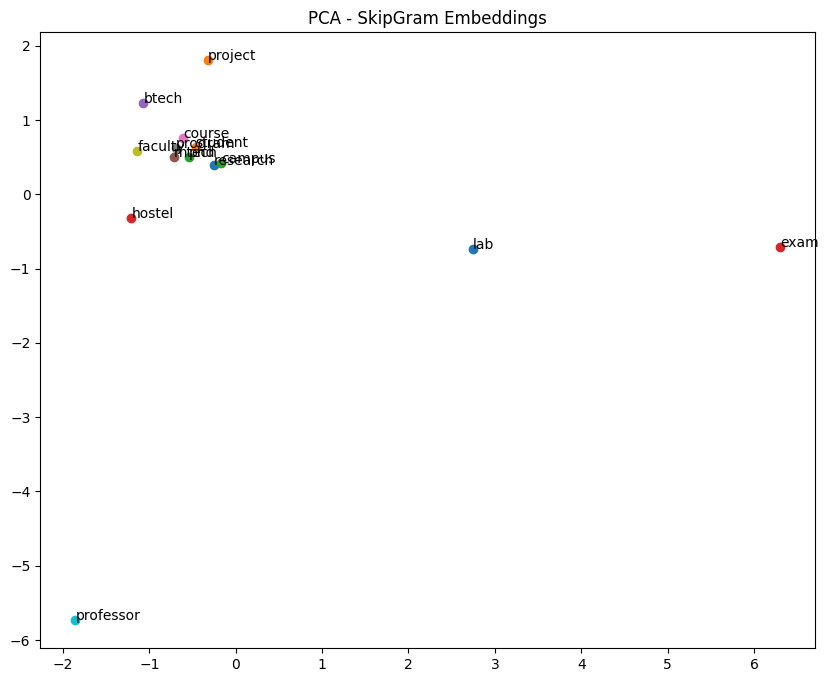

In [44]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

selected_words = [
    "research", "student", "phd", "exam",
    "btech", "mtech", "course", "program",
    "faculty", "professor", "lab", "project",
    "campus", "hostel"
]

# Keep only words in vocab
# selected_words = [w for w in selected_words if w in word2idx]
indices = [word2idx[w] for w in selected_words]

sg_vecs = sg_embeddings[indices]

pca = PCA(n_components=2)
sg_2d = pca.fit_transform(sg_vecs)

plt.figure(figsize=(10,8))

for i, word in enumerate(selected_words):
    plt.scatter(sg_2d[i,0], sg_2d[i,1])
    plt.text(sg_2d[i,0], sg_2d[i,1], word)

plt.title("PCA - SkipGram Embeddings")
# plt.savefig("pca_skipgram_numpy.png", dpi=300)
plt.show()

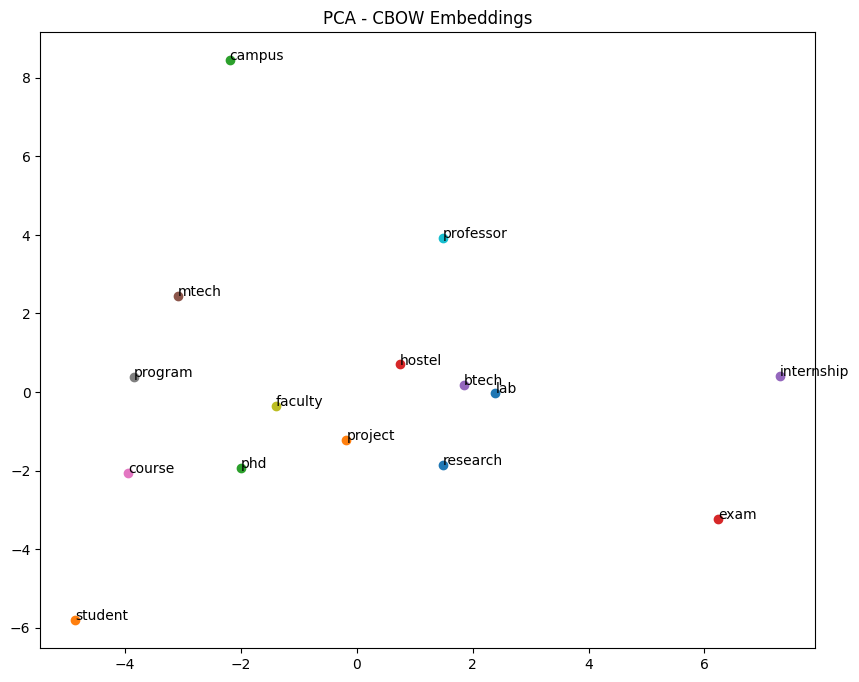

In [ ]:
cbow_vecs = cbow_embeddings[indices]

pca = PCA(n_components=2)
cbow_2d = pca.fit_transform(cbow_vecs)

plt.figure(figsize=(10,8))

for i, word in enumerate(selected_words):
    plt.scatter(cbow_2d[i,0], cbow_2d[i,1])
    plt.text(cbow_2d[i,0], cbow_2d[i,1], word)

plt.title("PCA - CBOW Embeddings")
# plt.savefig("pca_cbow_numpy.png", dpi=300)
plt.show()

C:\Users\S.M.Varshit\AppData\Roaming\Python\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\S.M.Varshit\AppData\Roaming\Python\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\S.M.Varshit\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\S.M.Varshit\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1024, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,


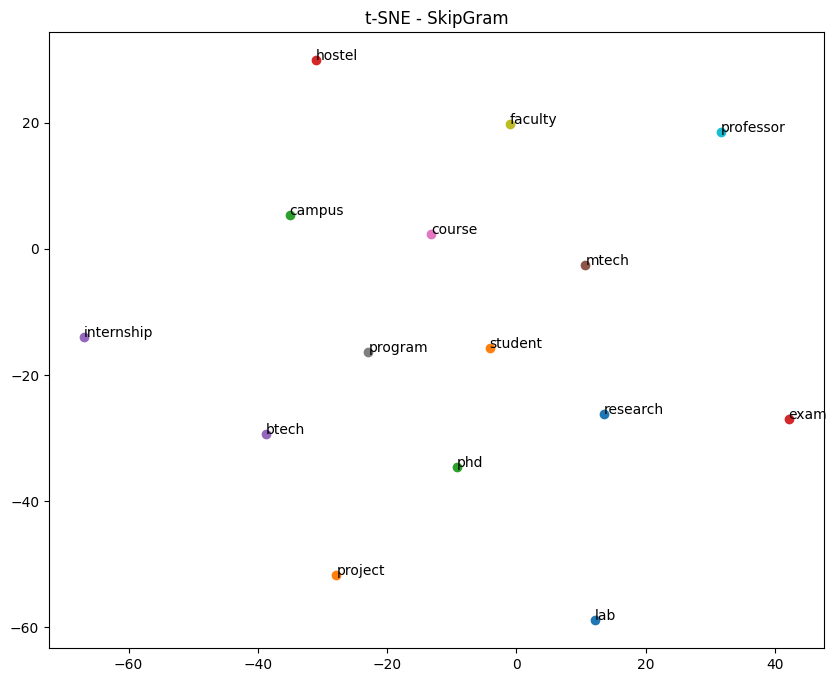

In [26]:
tsne = TSNE(n_components=2, perplexity=10, random_state=42)

sg_tsne = tsne.fit_transform(sg_vecs)

plt.figure(figsize=(10,8))

for i, word in enumerate(selected_words):
    plt.scatter(sg_tsne[i,0], sg_tsne[i,1])
    plt.text(sg_tsne[i,0], sg_tsne[i,1], word)

plt.title("t-SNE - SkipGram")
# plt.savefig("tsne_skipgram_numpy.png", dpi=300)
plt.show()

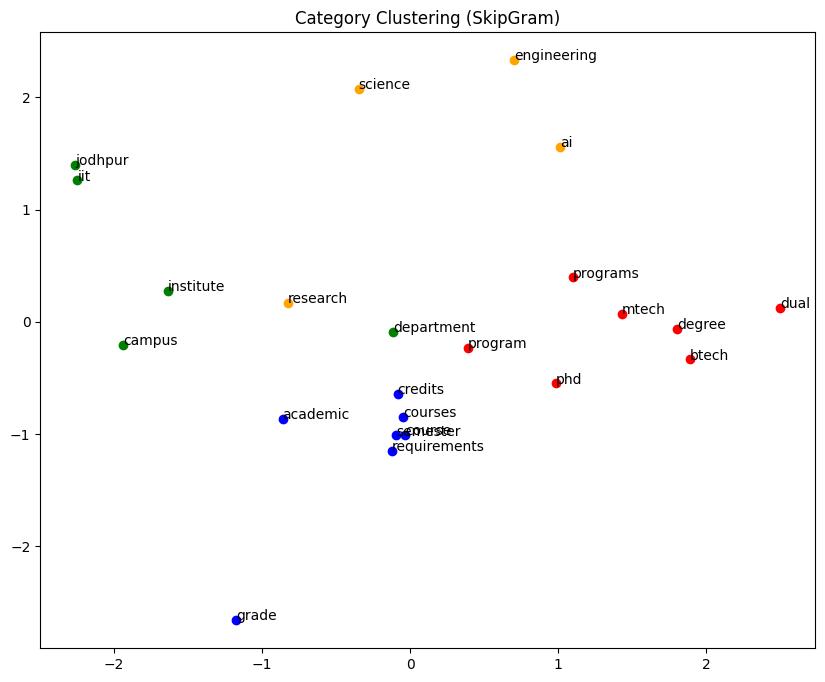

In [45]:
# categories = {
#     "Programs": ["btech", "mtech", "phd", "degree", "dual", "program", "programs"],
#     "Academics": ["course", "courses", "semester", "academic", "credits", "grade", "requirements"],
#     "Institute": ["institute", "department", "campus", "iit", "jodhpur"],
#     "Research": ["research", "science", "engineering", "ai"]
# }

# colors = ["red", "blue", "green", "orange"]

# plt.figure(figsize=(10,8))

# for (cat, words), color in zip(categories.items(), colors):
#     words = [w for w in words if w in word2idx]
#     idxs = [word2idx[w] for w in words]

#     vecs = sg_embeddings[idxs]
#     vecs_2d = PCA(n_components=2).fit_transform(vecs)

#     for i, word in enumerate(words):
#         plt.scatter(vecs_2d[i,0], vecs_2d[i,1], color=color)
#         plt.text(vecs_2d[i,0], vecs_2d[i,1], word)

# plt.title("Category Clustering (SkipGram)")
# # plt.savefig("category_clusters_numpy.png", dpi=300)
# plt.show()

categories = {
    "Programs": ["btech", "mtech", "phd", "degree", "dual", "program", "programs"],
    "Academics": ["course", "courses", "semester", "academic", "credits", "grade", "requirements"],
    "Institute": ["institute", "department", "campus", "iit", "jodhpur"],
    "Research": ["research", "science", "engineering", "ai"]
}

colors = ["red", "blue", "green", "orange"]

plt.figure(figsize=(10,8))

all_vecs = []
all_words = []
all_colors = []

# Step 1: Collect everything
for (cat, words), color in zip(categories.items(), colors):
    words = [w for w in words if w in word2idx]
    idxs = [word2idx[w] for w in words]

    vecs = sg_embeddings[idxs]

    all_vecs.extend(vecs)
    all_words.extend(words)
    all_colors.extend([color] * len(words))

# Step 2: Fit PCA once
pca = PCA(n_components=2)
all_vecs_2d = pca.fit_transform(all_vecs)

# Step 3: Plot
for i, word in enumerate(all_words):
    plt.scatter(all_vecs_2d[i, 0], all_vecs_2d[i, 1], color=all_colors[i])
    plt.text(all_vecs_2d[i, 0], all_vecs_2d[i, 1], word)

plt.title("Category Clustering (SkipGram)")
plt.savefig("category_clusters_numpy.png", dpi=300)
plt.show()

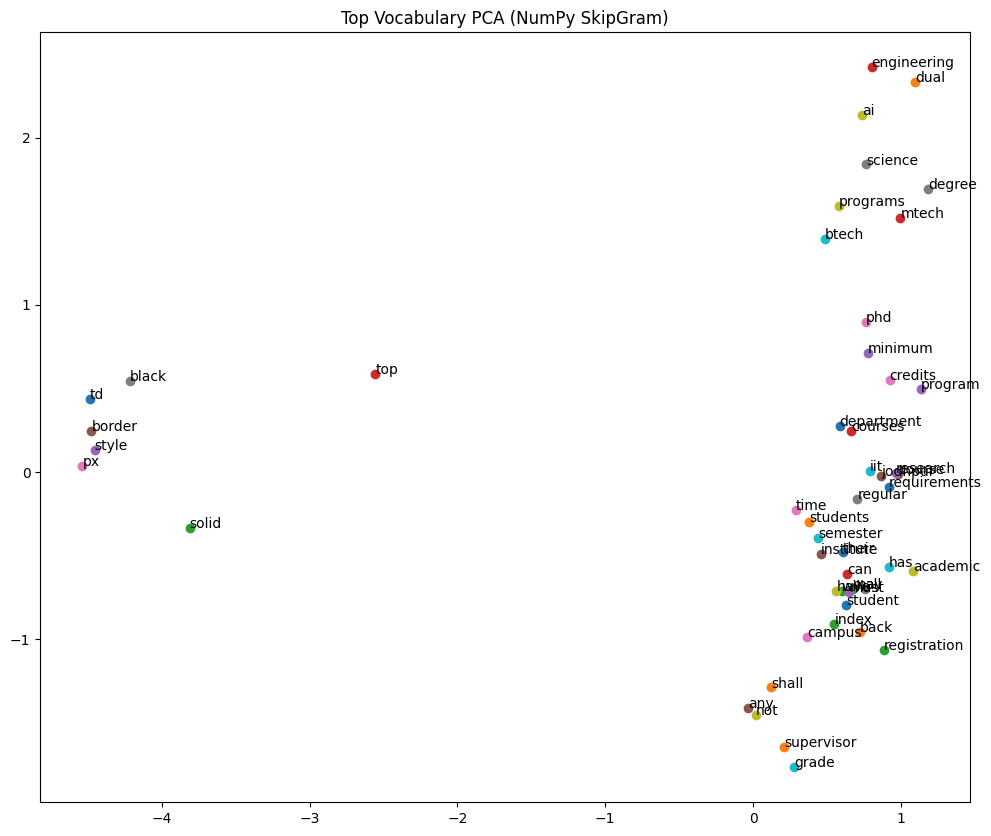

In [38]:
top_words = [w for w, _ in word_counts.most_common(50)]

idxs = [word2idx[w] for w in top_words]
vecs = sg_embeddings[idxs]

pca = PCA(n_components=2)
vecs_2d = pca.fit_transform(vecs)

plt.figure(figsize=(12,10))

for i, word in enumerate(top_words):
    plt.scatter(vecs_2d[i,0], vecs_2d[i,1])
    plt.text(vecs_2d[i,0], vecs_2d[i,1], word)

plt.title("Top Vocabulary PCA (NumPy SkipGram)")
# plt.savefig("top_vocab_numpy.png", dpi=300)
plt.show()

In [31]:
word_freq = Counter(all_tokens)
print(word_freq)

Counter({'student': 248, 'students': 217, 'will': 211, 'mtech': 181, 'program': 166, 'course': 165, 'phd': 164, 'degree': 148, 'academic': 145, 'semester': 131, 'requirements': 119, 'back': 113, 'index': 112, 'courses': 110, 'research': 100, 'institute': 99, 'credits': 98, 'all': 94, 'have': 94, 'iit': 93, 'td': 88, 'dual': 86, 'may': 83, 'can': 83, 'minimum': 82, 'jodhpur': 80, 'time': 79, 'science': 73, 'not': 73, 'grade': 66, 'department': 66, 'shall': 64, 'registration': 63, 'engineering': 63, 'style': 63, 'any': 62, 'campus': 61, 'regular': 61, 'ai': 61, 'has': 60, 'their': 60, 'supervisor': 60, 'solid': 59, 'top': 59, 'must': 57, 'border': 57, 'px': 57, 'black': 57, 'programs': 54, 'btech': 53, 'admission': 52, 'other': 51, 'through': 50, 'vertical': 50, 'align': 50, 'examination': 49, 'cgpa': 49, 'download': 48, 'file': 48, 'part': 47, 'table': 47, 'who': 46, 'per': 46, 'evaluation': 45, 'year': 45, 'msc': 45, 'if': 45, 'programmes': 44, 'programme': 43, 'thesis': 43, 'senate': 

In [ ]:
word_counts.most_common(50)

[('student', 248),
 ('students', 217),
 ('will', 211),
 ('mtech', 181),
 ('program', 166),
 ('course', 165),
 ('phd', 164),
 ('degree', 148),
 ('academic', 145),
 ('semester', 131),
 ('requirements', 119),
 ('back', 113),
 ('index', 112),
 ('courses', 110),
 ('research', 100),
 ('institute', 99),
 ('credits', 98),
 ('all', 94),
 ('have', 94),
 ('iit', 93),
 ('td', 88),
 ('dual', 86),
 ('may', 83),
 ('can', 83),
 ('minimum', 82),
 ('jodhpur', 80),
 ('time', 79),
 ('science', 73),
 ('not', 73),
 ('grade', 66),
 ('department', 66),
 ('shall', 64),
 ('registration', 63),
 ('engineering', 63),
 ('style', 63),
 ('any', 62),
 ('campus', 61),
 ('regular', 61),
 ('ai', 61),
 ('has', 60),
 ('their', 60),
 ('supervisor', 60),
 ('solid', 59),
 ('top', 59),
 ('must', 57),
 ('border', 57),
 ('px', 57),
 ('black', 57),
 ('programs', 54),
 ('btech', 53)]

# Comparision

In [2]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [3]:
def analyse_embeddings(sg_embeddings, cbow_embeddings):
    print("\n=== Nearest Neighbors (SkipGram) ===")

    words = ["research", "student", "phd", "exam"]

    for w in words:
        neighbors = get_nearest_neighbors(w, sg_embeddings)
        print(f"{w} -> {neighbors}")

    print("\n=== Analogies ===")

    print("UG : BTech :: PG :", analogy("ug", "btech", "pg", sg_embeddings))
    print("student : professor :: phd :", analogy("student", "professor", "phd", sg_embeddings))
    print("exam : test :: assignment :", analogy("exam", "test", "assignment", sg_embeddings))

    print("\n=== Nearest Neighbors (CBOW) ===")

    for w in words:
        neighbors = get_nearest_neighbors(w, cbow_embeddings)
        print(f"\n{w} ->")
        for neigh, score in neighbors:
            print(f"   {neigh:15s}  {score:.4f}")

    print("\n=== Analogies ===")

    print("UG : BTech :: PG :", analogy("ug", "btech", "pg", cbow_embeddings))
    print("student : professor :: phd :", analogy("student", "professor", "phd", cbow_embeddings))
    print("exam : test :: assignment :", analogy("exam", "test", "assignment", cbow_embeddings))

    categories = {
        "Programs": ["btech", "mtech", "phd", "degree", "dual", "program", "programs"],
        "Academics": ["course", "courses", "semester", "academic", "credits", "grade", "requirements"],
        "Institute": ["institute", "department", "campus", "iit", "jodhpur"],
        "Research": ["research", "science", "engineering", "ai"]
    }

    colors = ["red", "blue", "green", "orange"]

    plt.figure(figsize=(10,8))

    all_sg_vecs = []
    all_cbow_vecs = []
    all_words = []
    all_colors = []

    # Step 1: Collect everything
    for (cat, words), color in zip(categories.items(), colors):
        words = [w for w in words if w in word2idx]
        idxs = [word2idx[w] for w in words]

        sg_vecs = sg_embeddings[idxs]
        cbow_vecs = cbow_embeddings[idxs]

        all_sg_vecs.extend(sg_vecs)
        all_cbow_vecs.extend(cbow_vecs)
        all_words.extend(words)
        all_colors.extend([color] * len(words))

    pca_sg = PCA(n_components=2)
    all_sg_vecs_2d = pca_sg.fit_transform(all_sg_vecs)

    for i, word in enumerate(all_words):
        plt.scatter(all_sg_vecs_2d[i, 0], all_sg_vecs_2d[i, 1], color=all_colors[i])
        plt.text(all_sg_vecs_2d[i, 0], all_sg_vecs_2d[i, 1], word)

    plt.title("Category Clustering (SkipGram)")
    plt.savefig("category_clusters_sg_numpy.png", dpi=300)
    plt.show()


    pca_cbow = PCA(n_components=2)
    all_cbow_vecs_2d = pca_cbow.fit_transform(all_cbow_vecs)

    for i, word in enumerate(all_words):
        plt.scatter(all_cbow_vecs_2d[i, 0], all_cbow_vecs_2d[i, 1], color=all_colors[i])
        plt.text(all_cbow_vecs_2d[i, 0], all_cbow_vecs_2d[i, 1], word)

    plt.title("Category Clustering (CBOW)")
    plt.savefig("category_clusters_cbow_numpy.png", dpi=300)
    plt.show()


    top_words = [w for w, _ in word_counts.most_common(50)]

    idxs = [word2idx[w] for w in top_words]
    vecs = sg_embeddings[idxs]

    pca = PCA(n_components=2)
    vecs_2d = pca.fit_transform(vecs)

    plt.figure(figsize=(12,10))

    for i, word in enumerate(top_words):
        plt.scatter(vecs_2d[i,0], vecs_2d[i,1])
        plt.text(vecs_2d[i,0], vecs_2d[i,1], word)

    plt.title("Top Vocabulary PCA (NumPy SkipGram)")
    plt.savefig("top_vocab_numpy.png", dpi=300)
    plt.show()

## 1) Varying Dimension

In [4]:
sg_data = generate_skipgram_data(indexed_corpus, 5)

sg_embeddings = train_skipgram(
    sg_data,
    dim=20,
    neg_samples=5,
    epochs=50
)

[SkipGram] Epoch 1, Loss: 1077894.4582
[SkipGram] Epoch 5, Loss: 334411.3994
[SkipGram] Epoch 10, Loss: 284482.6636
[SkipGram] Epoch 15, Loss: 256869.5719
[SkipGram] Epoch 20, Loss: 239368.9732
[SkipGram] Epoch 25, Loss: 228949.3231
[SkipGram] Epoch 30, Loss: 221303.6177
[SkipGram] Epoch 35, Loss: 215737.2482
[SkipGram] Epoch 40, Loss: 212541.5623
[SkipGram] Epoch 45, Loss: 209271.2747
[SkipGram] Epoch 50, Loss: 206555.5494


In [5]:
cbow_data = generate_cbow_data(indexed_corpus, 5)

cbow_embeddings = train_cbow(
    cbow_data,
    dim=20,
    epochs=50
)

[CBOW] Epoch 1, Loss: 14299.8872
[CBOW] Epoch 5, Loss: 11490.9715
[CBOW] Epoch 10, Loss: 9140.7967
[CBOW] Epoch 15, Loss: 7293.0695
[CBOW] Epoch 20, Loss: 5858.2119
[CBOW] Epoch 25, Loss: 4751.5832
[CBOW] Epoch 30, Loss: 3895.8051
[CBOW] Epoch 35, Loss: 3229.4880
[CBOW] Epoch 40, Loss: 2705.1795
[CBOW] Epoch 45, Loss: 2287.8967
[CBOW] Epoch 50, Loss: 1952.2980



=== Nearest Neighbors (SkipGram) ===
research -> [('focused', 0.8703408548028404), ('high', 0.8096947844490874), ('coursework', 0.7779843539847748), ('driven', 0.7770806945097324), ('highlights', 0.770452680051318)]
student -> [('candidacy', 0.908948577003392), ('liable', 0.8436390164831157), ('after', 0.8274590102962063), ('before', 0.8266928013017542), ('enrolled', 0.8067457326677946)]
phd -> [('mtech', 0.8766815699026861), ('dual', 0.86275964011909), ('degree', 0.8559990238408645), ('program', 0.8220708311334353), ('high', 0.7793694386017304)]
exam -> [('seminar', 0.7654015791276855), ('art', 0.7647526205690798), ('give', 0.7594336003629336), ('state', 0.7519283102796073), ('temporarily', 0.7508200355353636)]

=== Analogies ===
UG : BTech :: PG : ['programmes', 'postgraduate', 'reservation']
student : professor :: phd : ['college', 'head', 'rolling']
exam : test :: assignment : ['type', 'sanction', 'description']

=== Nearest Neighbors (CBOW) ===

research ->
   requirements     0.

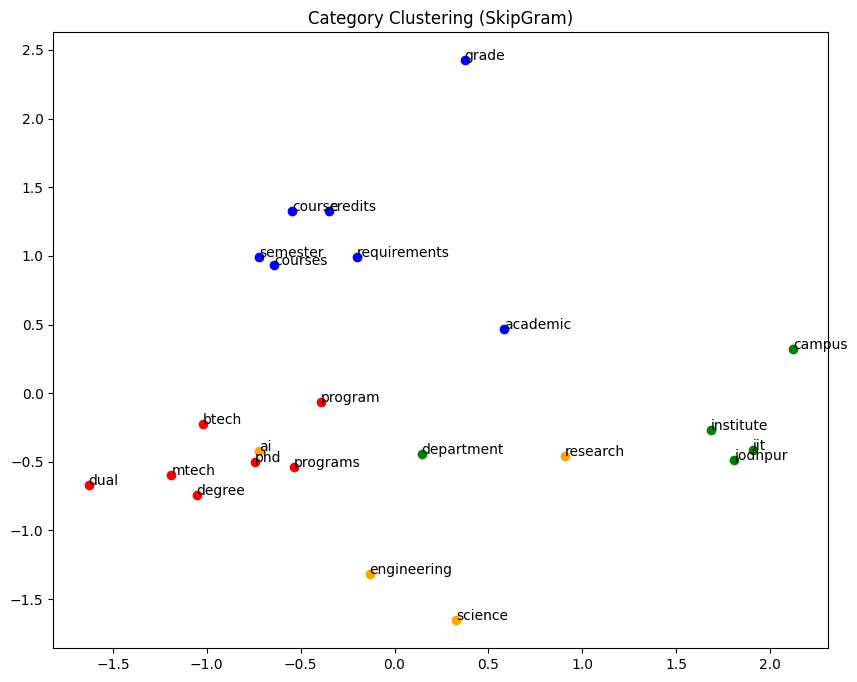

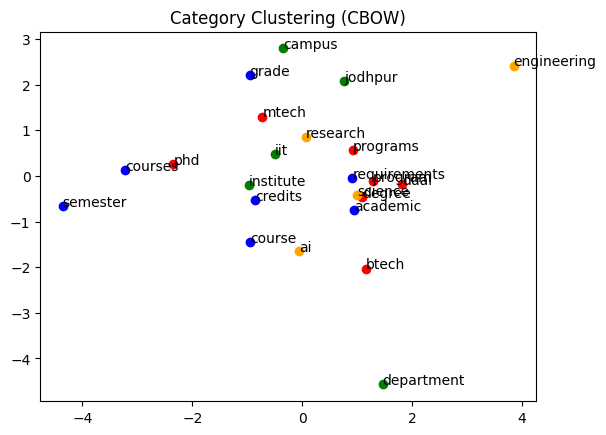

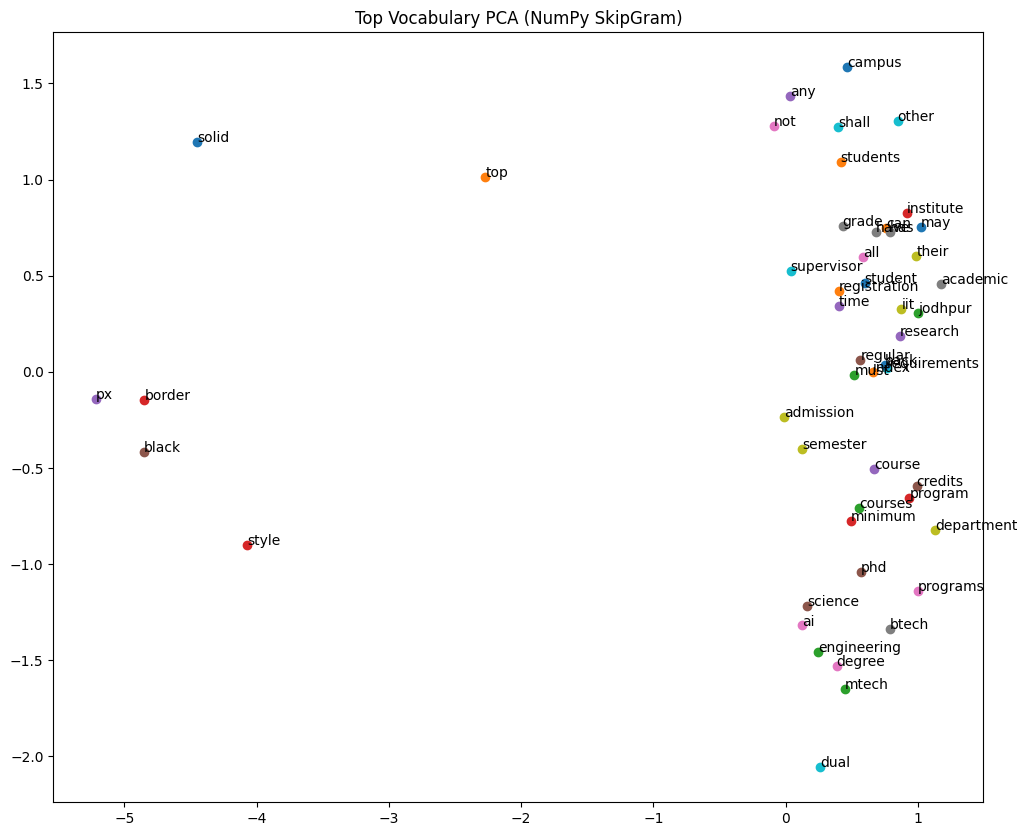

In [9]:
analyse_embeddings(sg_embeddings, cbow_embeddings)

In [20]:
sg_data = generate_skipgram_data(indexed_corpus, 5)

sg_embeddings = train_skipgram(
    sg_data,
    dim=100,
    neg_samples=5,
    epochs=50
)

[SkipGram] Epoch 1, Loss: 2281138.4743
[SkipGram] Epoch 5, Loss: 425037.4074
[SkipGram] Epoch 10, Loss: 265062.8269
[SkipGram] Epoch 15, Loss: 214322.9400
[SkipGram] Epoch 20, Loss: 191773.2518
[SkipGram] Epoch 25, Loss: 179452.1092
[SkipGram] Epoch 30, Loss: 171282.0211
[SkipGram] Epoch 35, Loss: 165272.8812
[SkipGram] Epoch 40, Loss: 159782.2067
[SkipGram] Epoch 45, Loss: 156455.1937
[SkipGram] Epoch 50, Loss: 153902.3300


In [21]:
cbow_data = generate_cbow_data(indexed_corpus, 5)

cbow_embeddings = train_cbow(
    cbow_data,
    dim=100,
    epochs=50
)

[CBOW] Epoch 1, Loss: 22261.9458
[CBOW] Epoch 5, Loss: 11835.3288
[CBOW] Epoch 10, Loss: 6625.3695
[CBOW] Epoch 15, Loss: 4023.7921
[CBOW] Epoch 20, Loss: 2592.6307
[CBOW] Epoch 25, Loss: 1767.0790
[CBOW] Epoch 30, Loss: 1272.0017
[CBOW] Epoch 35, Loss: 963.6377
[CBOW] Epoch 40, Loss: 763.5347
[CBOW] Epoch 45, Loss: 627.5271
[CBOW] Epoch 50, Loss: 530.7502



=== Nearest Neighbors (SkipGram) ===
research -> [('subjects', 0.5351310636580988), ('industry', 0.5235552083344576), ('work', 0.5018258420151631), ('phd', 0.4711967708450672), ('pre', 0.464336455057565)]
student -> [('thesis', 0.535000150544346), ('should', 0.49000755847799127), ('dean', 0.47352766124996437), ('phd', 0.45578773765661984), ('no', 0.45305182124948284)]
phd -> [('mtech', 0.7586353864411369), ('dual', 0.6891090825224233), ('degree', 0.6294298463470838), ('msc', 0.5300644624578278), ('research', 0.4711967708450671)]
exam -> [('publications', 0.448759910025858), ('form', 0.44122442594720834), ('written', 0.4384741579892042), ('fulfillment', 0.43433051652917826), ('journals', 0.4340444847050003)]

=== Analogies ===
UG : BTech :: PG : ['msc', 'stated', 'department']
student : professor :: phd : ['senior', 'head', 'first']
exam : test :: assignment : ['automotive', 'actively', 'society']

=== Nearest Neighbors (CBOW) ===

research ->
   student          0.3851
   assignment  

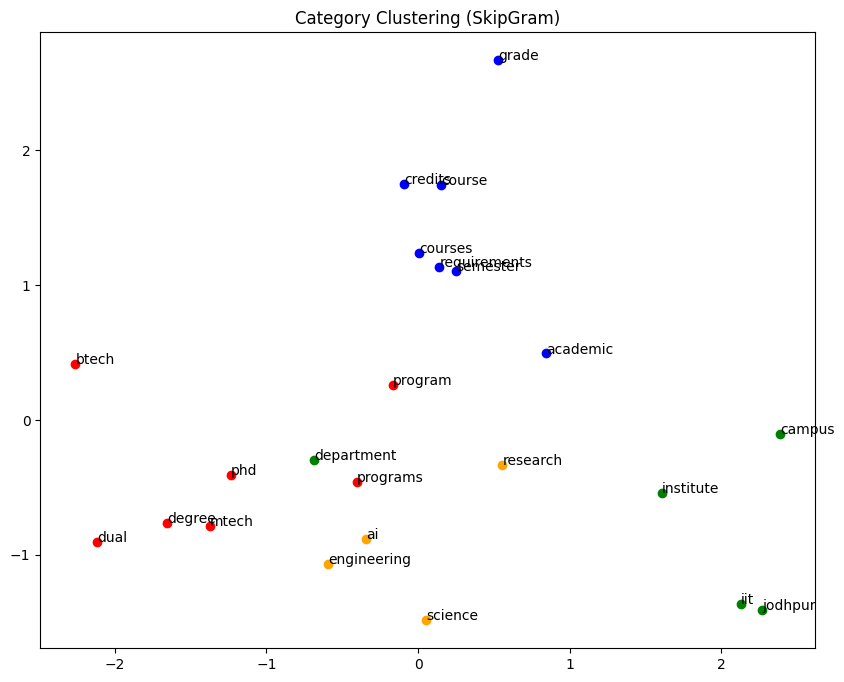

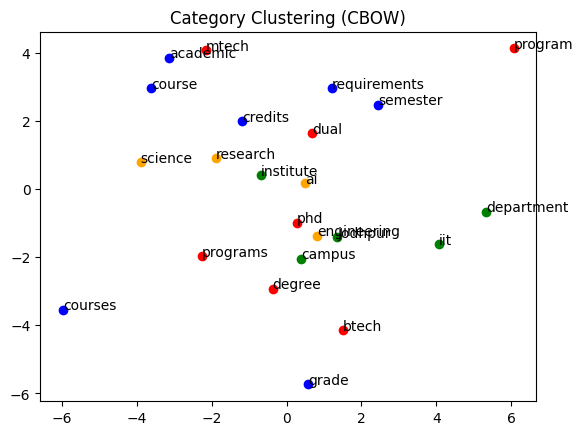

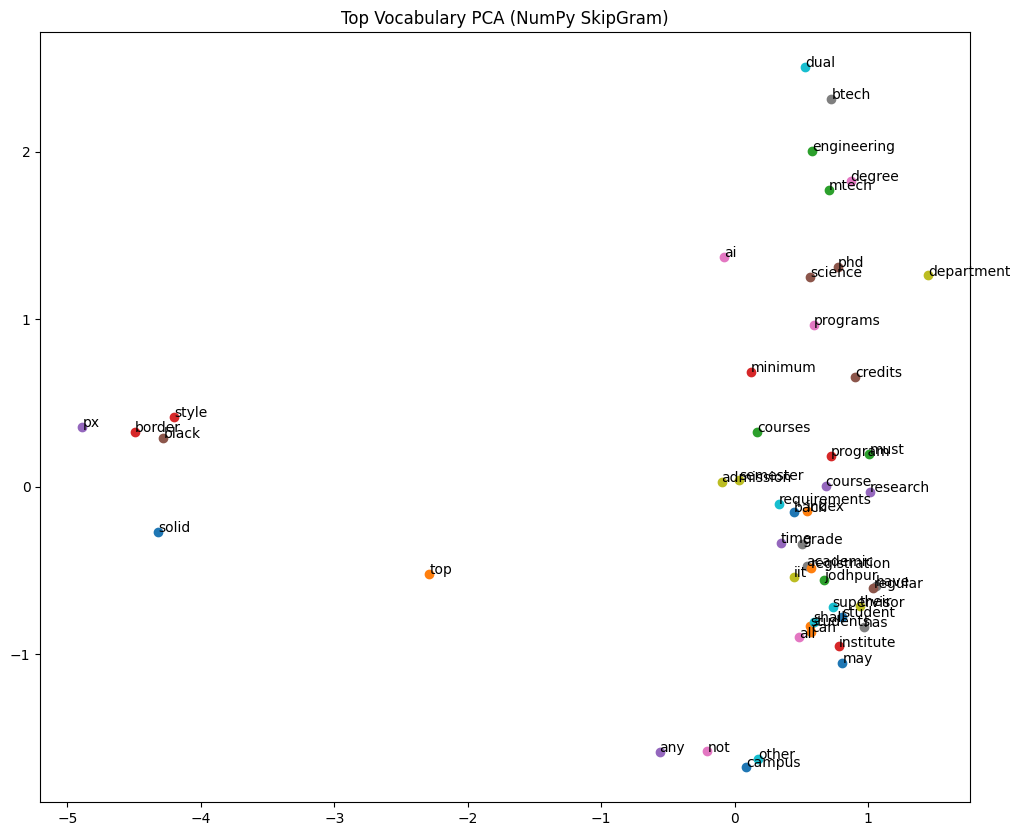

In [22]:
analyse_embeddings(sg_embeddings, cbow_embeddings)

# Varying Window Size

In [10]:
sg_data = generate_skipgram_data(indexed_corpus, 2)

sg_embeddings = train_skipgram(
    sg_data,
    dim=100,
    neg_samples=5,
    epochs=50
)

[SkipGram] Epoch 1, Loss: 1214741.8230
[SkipGram] Epoch 5, Loss: 295859.5525
[SkipGram] Epoch 10, Loss: 142293.6431
[SkipGram] Epoch 15, Loss: 96728.0485
[SkipGram] Epoch 20, Loss: 76919.9701
[SkipGram] Epoch 25, Loss: 66400.6748
[SkipGram] Epoch 30, Loss: 60106.9547
[SkipGram] Epoch 35, Loss: 55831.2554
[SkipGram] Epoch 40, Loss: 52112.6924
[SkipGram] Epoch 45, Loss: 48717.0817
[SkipGram] Epoch 50, Loss: 46976.0596


In [11]:
cbow_data = generate_cbow_data(indexed_corpus, 2)

cbow_embeddings = train_cbow(
    cbow_data,
    dim=100,
    epochs=50
)

[CBOW] Epoch 1, Loss: 30592.9372
[CBOW] Epoch 5, Loss: 12213.7093
[CBOW] Epoch 10, Loss: 5134.6371
[CBOW] Epoch 15, Loss: 2411.6281
[CBOW] Epoch 20, Loss: 1274.9673
[CBOW] Epoch 25, Loss: 784.6701
[CBOW] Epoch 30, Loss: 556.9894
[CBOW] Epoch 35, Loss: 435.5608
[CBOW] Epoch 40, Loss: 360.0306
[CBOW] Epoch 45, Loss: 307.6416
[CBOW] Epoch 50, Loss: 268.8426



=== Nearest Neighbors (SkipGram) ===
research -> [('taken', 0.46315155089954874), ('laboratories', 0.4506744686367288), ('terminated', 0.438641115467764), ('join', 0.4274626886545613), ('work', 0.42158030457276613)]
student -> [('must', 0.48690814960559803), ('shall', 0.45739698251510763), ('shortlisted', 0.4483013418224727), ('gate', 0.4431106929959631), ('candidate', 0.43700010373180637)]
phd -> [('mtech', 0.6437369031357908), ('degree', 0.4888414021824845), ('admission', 0.487939664819214), ('dual', 0.4816550110183856), ('programme', 0.4680021581910889)]
exam -> [('mo', 0.4770430558022749), ('corresponding', 0.44424868961774333), ('bsc', 0.44055104711354787), ('sections', 0.4350229462003665), ('across', 0.4339426892161077)]

=== Analogies ===
UG : BTech :: PG : ['bachelor', 'guidelines', 'pending']
student : professor :: phd : ['stop', 'residence', 'mtech']
exam : test :: assignment : ['able', 'regarding', 'alone']

=== Nearest Neighbors (CBOW) ===

research ->
   library          

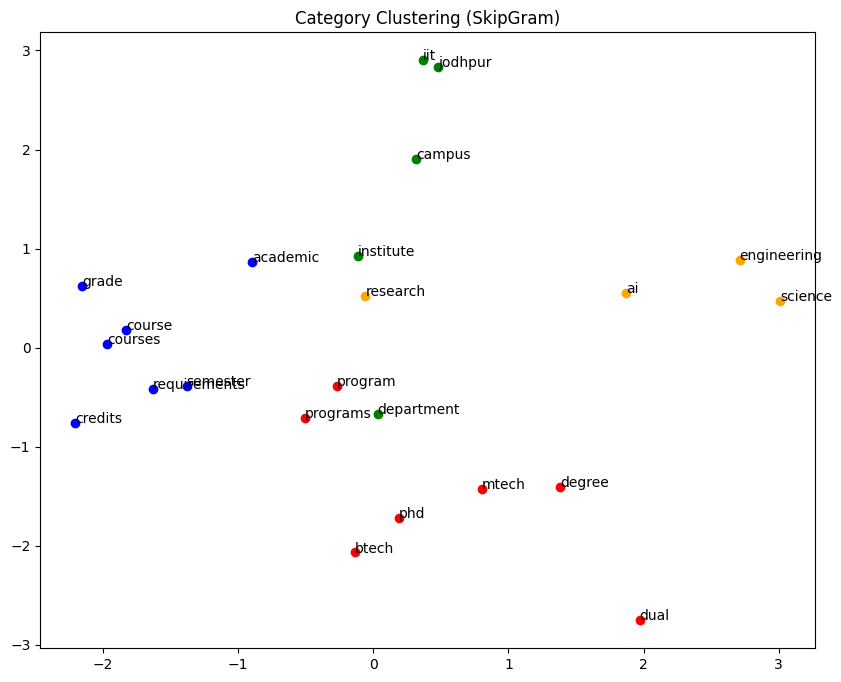

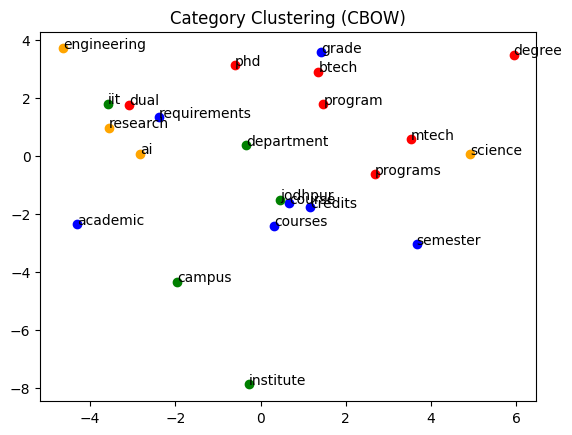

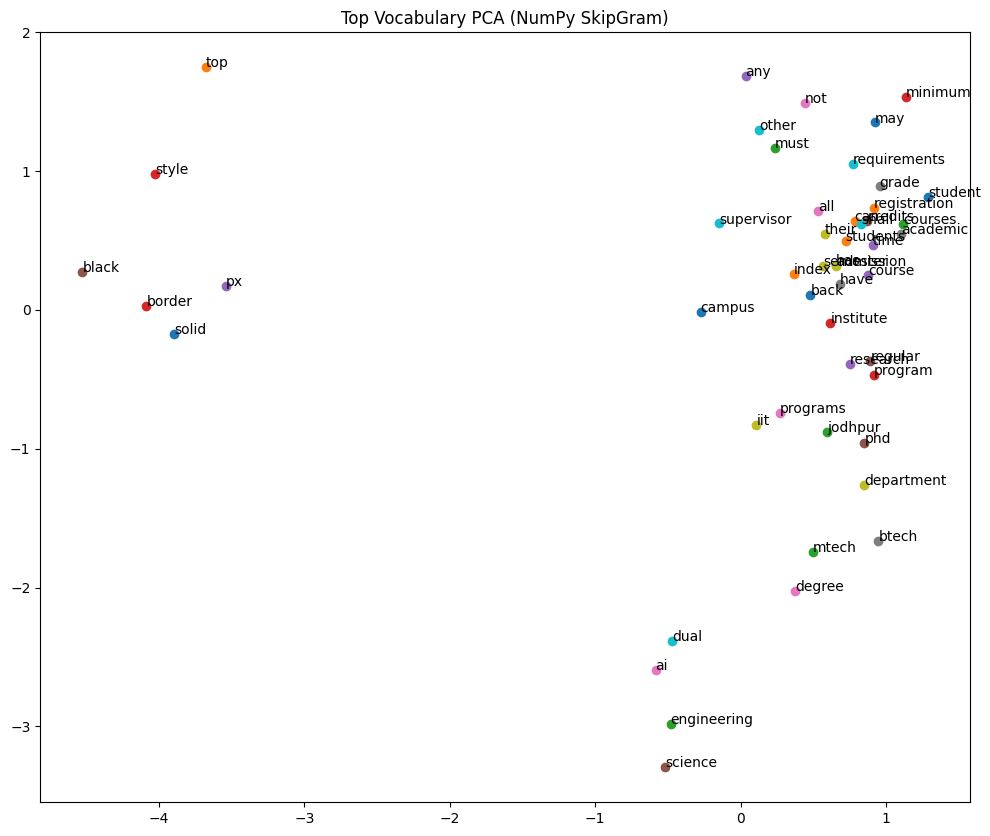

In [12]:
analyse_embeddings(sg_embeddings, cbow_embeddings)

# Varying Negative Sampling 

In [ ]:
sg_data = generate_skipgram_data(indexed_corpus, 5)

sg_embeddings = train_skipgram(
    sg_data,
    dim=100,
    neg_samples=2,
    epochs=50
)

In [ ]:
analyse_embeddings(sg_embeddings, cbow_embeddings)

In [ ]:
sg_data = generate_skipgram_data(indexed_corpus, 5)

sg_embeddings = train_skipgram(
    sg_data,
    dim=100,
    neg_samples=10,
    epochs=50
)

In [ ]:
analyse_embeddings(sg_embeddings, cbow_embeddings)

In [14]:
top_10 = word_counts.most_common(10)

for word, freq in top_10:
    print(f"{word}, {freq}")

student, 248
students, 218
mtech, 181
program, 166
course, 165
phd, 164
degree, 148
academic, 147
semester, 131
requirements, 119


In [15]:
sg_data = generate_skipgram_data(indexed_corpus, 5)

sg_embeddings = train_skipgram(
    sg_data,
    dim=300,
    neg_samples=2,
    epochs=50
)

[SkipGram] Epoch 1, Loss: 2273316.5616
[SkipGram] Epoch 5, Loss: 607676.0007
[SkipGram] Epoch 10, Loss: 264467.5484
[SkipGram] Epoch 15, Loss: 173230.9803
[SkipGram] Epoch 20, Loss: 139338.4527
[SkipGram] Epoch 25, Loss: 123691.2528
[SkipGram] Epoch 30, Loss: 114204.8103
[SkipGram] Epoch 35, Loss: 109576.6854
[SkipGram] Epoch 40, Loss: 106042.9165
[SkipGram] Epoch 45, Loss: 103362.3517
[SkipGram] Epoch 50, Loss: 101788.6272


In [19]:
word = "research"  # choose your word

if word in word2idx:
    idx = word2idx[word]
    vec = sg_embeddings[idx]
    # print(len(vec))
    print(f"\n{word} - " + ", ".join([f"{v:.4f}" for v in vec]))
else:
    print(f"{word} not in vocabulary")


research - 0.0395, 0.1667, -0.3789, -0.1801, -0.1209, 0.1983, 0.5421, -0.0582, -0.0638, 0.1570, 0.0449, -0.2368, 0.0006, 0.2212, 0.1666, -0.1789, 0.6052, -0.1417, 0.3509, 0.0251, 0.1779, 0.3925, -0.3735, 0.4895, 0.0172, -0.8761, 0.4469, -0.1933, 0.3909, -0.1394, 0.1094, -0.3373, -0.3571, 0.0591, 0.3320, 0.4042, -0.0493, 0.1524, -0.5271, 0.4789, 0.2584, 0.1337, 0.2101, -0.3461, 0.3719, -0.1866, 0.2587, -0.3212, -0.1989, -0.0803, 0.5375, -0.2711, 0.1526, -0.2893, 0.0842, -0.3109, -0.5848, -0.0043, 0.1615, 0.3507, 0.2656, 0.4837, -0.4627, 0.2182, -0.0885, -0.0470, -0.6573, 0.1156, 0.0396, 0.9163, 0.2903, -0.3410, -0.2776, 0.1849, -0.3907, 0.0649, -0.6351, -0.2468, 0.5438, 0.2377, -0.3011, -0.0011, 0.5161, 0.5342, 0.0539, -0.2307, 0.1254, 0.1330, 0.2212, -0.5527, -0.4444, 0.2055, 0.3514, 0.4055, 0.6637, 0.0789, -0.2362, -0.0907, -0.2816, 0.4890, -0.0113, 0.1136, -0.5188, -0.1221, 0.0310, -0.3689, 0.1444, -0.3394, 0.2006, -0.3252, -0.1564, 0.4151, 0.3745, -0.0221, -0.0156, -0.7622, 0.2220,